In [1]:
# https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset

#Data Preprocessing

Before we perform our analysis on instacart we will prepare and clean the dataset.The Instacart Grocery dataset contains multiple tables describing users, orders, products, and purchase patterns.

In this preprocessing stage, we will:

*  Import relevant libraries
*  Load the datasets
*  Inspect structure and data types
*  Data Reduction
*  Handle missing values
*  Merge key datasets for analysis
*  Create helper features useful for future modeling and Exploratory Data Analysis (EDA)















In [1]:
import pandas as pd #import pandas library for data manipulation
import matplotlib.pyplot as plt #import matplotlib.pyplot for our visualisations
import seaborn as sns #import seaborn for our visualisations

##Load the datasets

In [2]:
# Read data from CSVs for aisles, departments, products, orders and orders_products_prior

aisles = pd.read_csv("./datasets/instacart/aisles.csv")
departments = pd.read_csv("./datasets/instacart/departments.csv")
products = pd.read_csv("./datasets/instacart/products.csv")
orders_all = pd.read_csv("./datasets/instacart/orders.csv")
order_products_prior = pd.read_csv("./datasets/instacart/order_products__prior.csv")


##Check Dataset Dimensions
This helps us understand the size and shape of each file.


In [3]:
#Check and print the total number of  records and fields are in our datasets
#This will allow us understand the size and shape of each file.

print(f"Aisles dataset has {aisles.shape[0]} records and {aisles.shape[1]} columns")
print(f"Departments dataset has {departments.shape[0]} records and {departments.shape[1]} columns")
print(f"Products dataset has {products.shape[0]} records and {products.shape[1]} columns")
print(f"Orders dataset has {orders_all.shape[0]} records and {orders_all.shape[1]} columns")
print(f"Order_products_prior dataset has {order_products_prior.shape[0]} records and {order_products_prior.shape[1]} columns")


Aisles dataset has 134 records and 2 columns
Departments dataset has 21 records and 2 columns
Products dataset has 49688 records and 4 columns
Orders dataset has 3421083 records and 7 columns
Order_products_prior dataset has 32434489 records and 4 columns


##Explore Dataset Structure

Now lets examine sample our dataset records


In [4]:
# Preview the first 5 rows of each dataset
print("1. Aisles")
display(aisles.head())
print("\n")
print("2. Departments")
display(departments.head())
print("\n")
print("3. Products")
display(products.head())
print("\n")
print("4. Orders")
display(orders_all.head())
print("\n")
print("5. Order products Prior")
display(order_products_prior.head())


1. Aisles


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation




2. Departments


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol




3. Products


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13




4. Orders


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0




5. Order products Prior


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


##Check for Missing Values

We will check for missing values so that they dont affect the accuracy of our analysis

In [6]:
#Print and check the total of missing values for each column in each dataset
print("\nOrders Missing Values Summary:")
print(orders_all.isnull().sum())
print("\nOrders Products Prior Missing Values Summary:")
print(order_products_prior.isnull().sum())
print("\nProducts Missing Values Summary:")
print(products.isnull().sum())
print("\nDepartments Missing Values Summary:")
print(departments.isnull().sum())
print("\nAisles Missing Values Summary:")
print(aisles.isnull().sum())


Orders Missing Values Summary:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Orders Products Prior Missing Values Summary:
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

Products Missing Values Summary:
product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

Departments Missing Values Summary:
department_id    0
department       0
dtype: int64

Aisles Missing Values Summary:
aisle_id    0
aisle       0
dtype: int64


##Handling Missing values
We replace missing days_since_prior_order with 0 because a missing value means the customer is placing their first order, so there is no previous gap. This keeps these customers in the dataset without fabricating unrealistic gaps

In [7]:
# Replace missing values for first orders with 0
orders_all['days_since_prior_order'] = orders_all['days_since_prior_order'].fillna(0).astype(int)


In [8]:
#Check again if we still have some missing values
print(orders_all.isnull().sum())

order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64


##Check for potential duplicates
We checked for duplicate rows to avoid double-counting orders or products, which would bias metrics like total orders and reorder rates.

In [9]:
# --------------------------------------------------
#  Check for duplicates in each dataset
# --------------------------------------------------

print("Duplicate rows:")

print(f"Aisles: {aisles.duplicated().sum()}")
print(f"Departments: {departments.duplicated().sum()}")
print(f"Products: {products.duplicated().sum()}")
print(f"Orders: {orders_all.duplicated().sum()}")
print(f"Order Products Prior: {order_products_prior.duplicated().sum()}")

Duplicate rows:
Aisles: 0
Departments: 0
Products: 0
Orders: 0
Order Products Prior: 0


##Data Reduction

In [10]:
#We will inspect the eval_set column to see what kind of splits are included
orders_all['eval_set'].unique()



array(['prior', 'train', 'test'], dtype=object)

In [11]:
#Filter the only for prior set

orders = orders_all[orders_all['eval_set'] == 'prior'].copy()

#We nolonger need eval_set, so lets drop and further reduce our data fotprint
orders.drop(columns=['eval_set'], axis=1,inplace=True)

orders.shape


(3214874, 6)

##Merge Key Datasets for Analysis
We merged orders with product, aisle, and department data so that later analyses like top products and reorder rates can be broken down by meaningful business categories.



In [12]:
# ---------------------------------------------------------------
#  Merge products, aisle and departments
# Drop the department id and aisle id - we no longer need it
# --------------------------------------------------------------
all_products = products.merge(aisles,
                              left_on="aisle_id",
                              right_on="aisle_id",
                              how="left")\
                             .merge(departments,
                                    left_on="department_id",
                                    right_on="department_id",how="left")\
                             .drop(columns=["aisle_id", "department_id"])


all_products


,product_id,product_name,aisle,department
0,1,Chocolate Sandwich Cookies,cookies cakes,snacks
1,2,All-Seasons Salt,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,frozen meals,frozen
4,5,Green Chile Anytime Sauce,marinades meat preparation,pantry
...,...,...,...,...
49683,49684,"Vodka, Triple Distilled, Twist of Vanilla",spirits,alcohol
49684,49685,En Croute Roast Hazelnut Cranberry,frozen vegan vegetarian,frozen
49685,49686,Artisan Baguette,bread,bakery
49686,49687,Smartblend Healthy Metabolism Dry Cat Food,cat food care,pets


In [13]:
# ------------------------------------------------------
# Merge orders and order_products_prior
# ------------------------------------------------------
order_columns = ['order_id','user_id', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

all_orders = order_products_prior.merge(orders[order_columns],
                          on="order_id",
                          how="left")


all_orders.head()




,order_id,product_id,add_to_cart_order,reordered,user_id,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,202279,5,9,8
1,2,28985,2,1,202279,5,9,8
2,2,9327,3,0,202279,5,9,8
3,2,45918,4,1,202279,5,9,8
4,2,30035,5,0,202279,5,9,8


In [14]:
# ------------------------------------------------------
# Merge products dimension to the orders dataset
# ------------------------------------------------------
all_orders = all_orders.merge(all_products,
                              on="product_id",
                              how="left")



In [15]:
# ------------------------------------------------------
# Check for missing values after merging
# ------------------------------------------------------
all_orders.isna().sum()

,0
order_id,0
product_id,0
add_to_cart_order,0
reordered,0
user_id,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,0
product_name,0
aisle,0


##Feature Engineering
We will create some additional feautures from our raw data to make our analysis more meaningfull

In [16]:
# We summarise each user's behaviour into the following:
# - total_orders: how engaged they are
# - avg_days_between_orders: how frequently they shop
# - avg_cart_size: how many items they typically buy
# These features drive our churn analysis.

user_features = all_orders.groupby('user_id').agg(
    user_total_orders=('order_id','nunique'),
    days_since_last_order=('days_since_prior_order','last'),
    avg_days_between_orders=('days_since_prior_order','mean'),
     total_products=('product_id','count')
).reset_index()

# Add average cart size
user_features['avg_cart_size'] = user_features['total_products'] / user_features['user_total_orders']
user_features['avg_cart_size'].round(0)
# RFM Segmentation
user_features['rfm_segment'] = pd.cut(user_features['user_total_orders'],
                                     bins=[0, 1, 3, 10, float('inf')],
                                     labels=['New', 'Occasional', 'Regular', 'VIP'])

# Cart Size Segmentation
user_features['cart_segment'] = pd.cut(user_features['avg_cart_size'],
                                      bins=[0, 5, 15, 30, float('inf')],
                                      labels=['Small', 'Medium', 'Large', 'Bulk'])

# Define churn risk based on long gaps between orders
user_features['churn_risk'] = (
    (user_features['days_since_last_order'] > user_features['avg_days_between_orders'] * 2) &
    (user_features['user_total_orders'] > 1)  # Exclude one-time customers
)

user_features.head()

,user_id,user_total_orders,days_since_last_order,avg_days_between_orders,total_products,avg_cart_size,rfm_segment,cart_segment,churn_risk
0,1,10,19,18.542373,59,5.900000,Regular,Medium,False
1,2,14,30,14.902564,195,13.928571,VIP,Medium,True
2,3,12,7,10.181818,88,7.333333,VIP,Medium,False
3,4,5,0,11.944444,18,3.600000,Regular,Small,False
4,5,4,0,10.189189,37,9.250000,Regular,Medium,False


In [17]:
# Aggregate at product level to understand:
# - total_orders: popularity
# - total_reorders: loyalty/repeat behaviour
# - avg_cart_position: whether items are added early or late in the basket
# Reorder rate helps us identify "habit" products customers keep coming back to.

product_summary = all_orders.groupby('product_id').agg(
    product_name=('product_name','first'),
    department=('department','first'),
    aisle=('aisle','first'),
    total_orders=('order_id','count'),
    unique_buyers=('user_id','nunique'),
    reorder_rate=('reordered','mean'),
    avg_cart_position=('add_to_cart_order','mean')
).reset_index()
product_summary['avg_cart_position'].round(0)
product_summary.head()

,product_id,product_name,department,aisle,total_orders,unique_buyers,reorder_rate,avg_cart_position
0,1,Chocolate Sandwich Cookies,snacks,cookies cakes,1852,716,0.613391,5.801836
1,2,All-Seasons Salt,pantry,spices seasonings,90,78,0.133333,9.888889
2,3,Robust Golden Unsweetened Oolong Tea,beverages,tea,277,74,0.732852,6.415162
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,frozen,frozen meals,329,182,0.446809,9.507599
4,5,Green Chile Anytime Sauce,pantry,marinades meat preparation,15,6,0.600000,6.466667


#Data Visualisation and Analysis

##Customer Level Analytics
###Distribution of Total Orders per customer

This distribution shows that most customers place only a few orders, while a smaller group has very high order counts. This suggests Instacart has a long tail of loyal power users that drive a significant share of volume



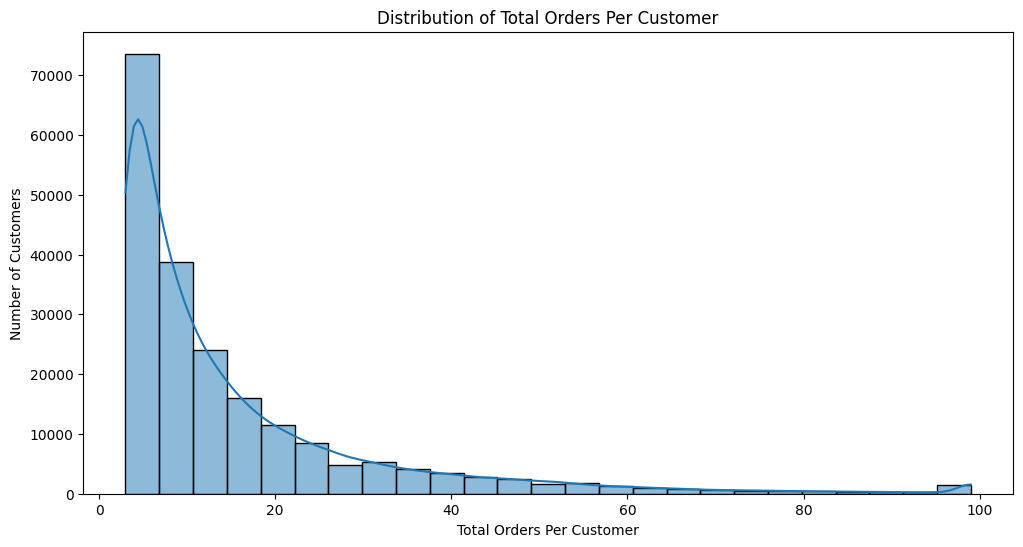

In [18]:

# Create a new figure with a custom size (width=12, height=6 inches)
plt.figure(figsize=(12,6))

# Plot a histogram of total orders per user, with a KDE (smoothed density curve) and 25 bins
sns.histplot(user_features['user_total_orders'], kde=True, bins=25)

# Add a title to the chart to describe what it shows
plt.title('Distribution of Total Orders Per Customer')

# Label the x-axis to show what the values represent
plt.xlabel('Total Orders Per Customer')

# Label the y-axis to indicate this is count of customers
plt.ylabel('Number of Customers')

# Display the final plot
plt.show()


###Distribution of Average Reorderd Days Between Orders
This data shows strong customer retention, with most users ordering every 1-2 weeks, providing predictable revenue and highlighting a valuable core customer segment for focused business strategies.

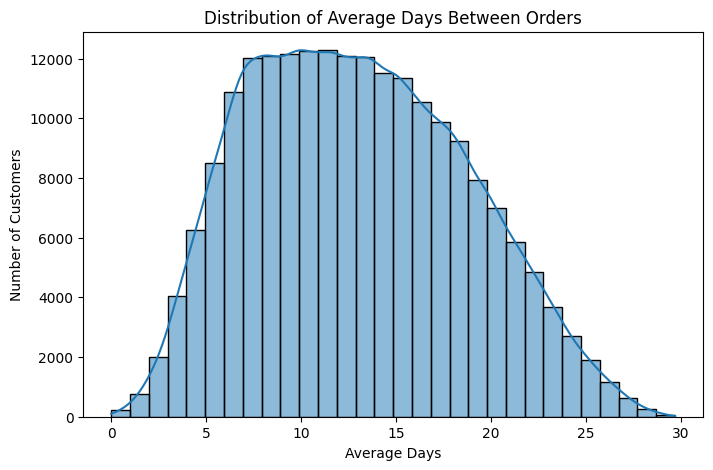

In [19]:
# Create a new figure and set its size (width=8, height=5 inches)
plt.figure(figsize=(8,5))

# Plot a histogram showing the distribution of the average number of days between customer orders,
# include a KDE curve to visualize the underlying trend and smooth the distribution,
# and break the values into 30 bins for detail.
sns.histplot(user_features['avg_days_between_orders'], kde=True, bins=30)

# Add a title describing what the visualization represents
plt.title('Distribution of Average Days Between Orders')

# Label the x-axis to show that the values represent the average number of days between customer purchases
plt.xlabel('Average Days')

# Label the y-axis to show the count of customers falling into each bin
plt.ylabel('Number of Customers')

# Display the plot
plt.show()


###Distribution of Average Cart Size

Most customers have small carts (1-10 items), indicating either focused shopping or low-value purchases, with a long tail of bulk buyers suggesting two distinct customer segments: frequent small-basket shoppers and occasional large-order customers.

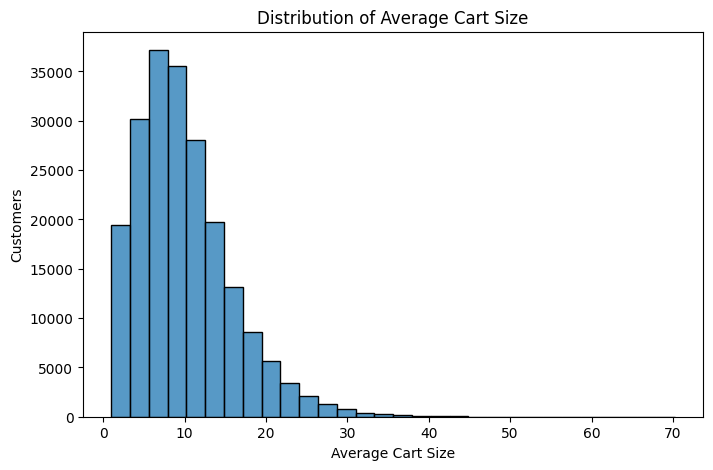

In [20]:
# Create a new figure with a custom size (width=8, height=5 inches)
plt.figure(figsize=(8,5))

# Plot a histogram showing the distribution of average cart size per customer,
# using 30 bins to segment the values into ranges
sns.histplot(user_features['avg_cart_size'], bins=30)

# Apply a clean background style to improve readability of the visualization
sns.set_style('whitegrid')

# Add a title to describe what the visualization represents
plt.title('Distribution of Average Cart Size')

# Label the x-axis to indicate that the values represent the average number of items customers add per order
plt.xlabel('Average Cart Size')

# Label the y-axis to show how many customers fall into each cart size range
plt.ylabel('Customers')

# Display the final plotted chart
plt.show()



###Customer Distribution by RFM Segment
The analysis reveals that all the customers are at least repeat customers. Instacart have an incredibly loyal customer base with strong retention, but may need to focus more on new customer acquisition for sustainable growth.

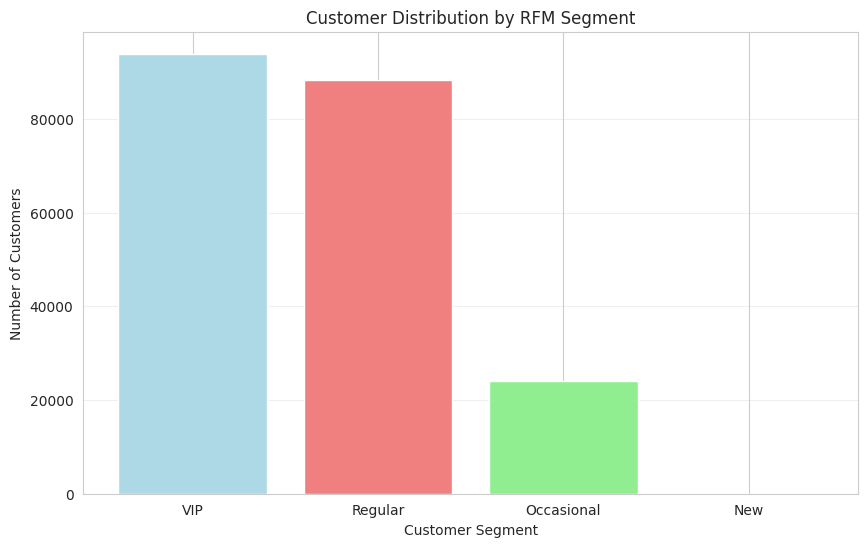

In [21]:
# Count how many customers fall into each RFM segment
segment_counts = user_features['rfm_segment'].value_counts()

# Sort the segment counts so bars appear in a consistent order
segment_counts.sort_values()

# Create a figure with defined size (width=10, height=6 inches)
plt.figure(figsize=(10, 6))

# Create a bar chart using the segment names as labels and their counts as bar heights
# Custom colors applied to visually differentiate each segment
plt.bar(segment_counts.index, segment_counts.values,
        color=['lightblue', 'lightcoral', 'lightgreen', 'gold'])

# Add a title describing what the chart represents
plt.title('Customer Distribution by RFM Segment')

# Label the x-axis to show the different customer categories
plt.xlabel('Customer Segment')

# Label the y-axis to indicate the number of customers in each segment
plt.ylabel('Number of Customers')

# Add grid lines to the y-axis for better readability of bar heights
plt.grid(axis='y', alpha=0.3)

# Display the completed bar chart
plt.show()


###Churn Risk Analysis
Below are the key findings from the churn analysis:

90.9% of users are classified as Not at Risk

9.1% of users fall into the Churn Risk category

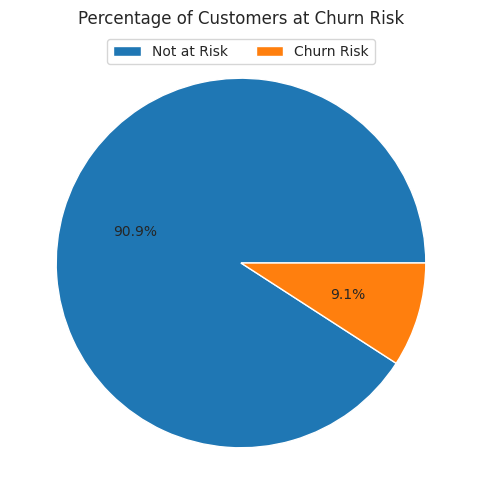

In [22]:
# Create a pie chart showing the proportion of customers marked as churn risk vs not at risk.
# 'value_counts()' counts how many customers fall in each category.
# 'figsize' defines the size of the plot.
user_features['churn_risk'].value_counts().plot(kind='pie',
                                                autopct='%1.1f%%',
                                                labels=None,
                                                figsize=(6,6))

# Add a title to explain what the chart represents.
plt.title('Percentage of Customers at Churn Risk')

# Add a custom legend to label the two categories instead of showing them on the slices.
plt.legend(['Not at Risk', 'Churn Risk'],
            loc='upper center', ncol=2)

# Remove the default y-axis label (pie charts don’t need it).
plt.ylabel('')

# Display the final visualization.
plt.show()


##Product Level Insights

We are going to perform product-level analytics to understand what customers are buying, how often, and which items drive repeat purchasing behavior

###Top 10 Most Frequently purchased Products
The customers strongly prefer fresh, organic produce, with bananas and avocados being the category leaders that likely drive frequent store visits


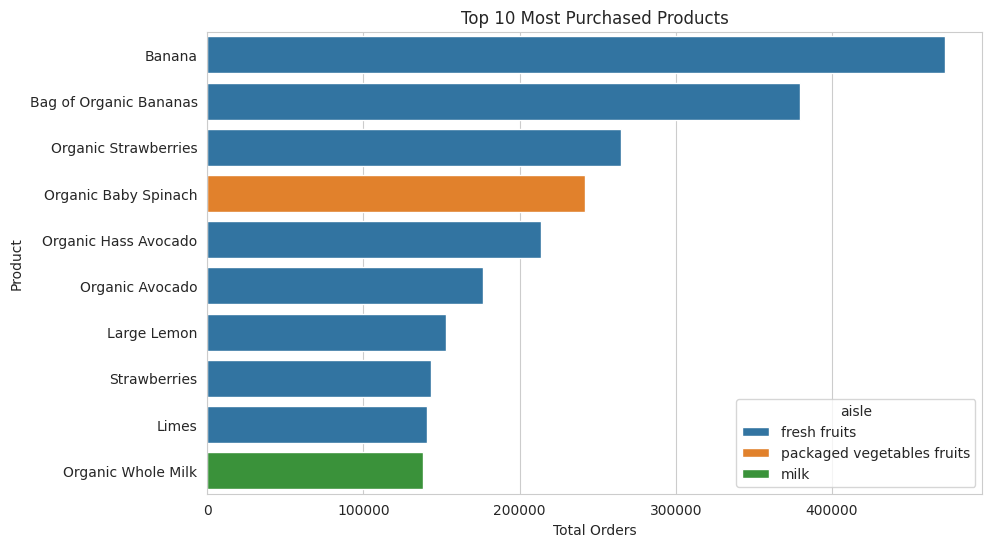

In [23]:
# Select the top 10 most frequently purchased products by sorting in descending order
top_products = product_summary.sort_values('total_orders', ascending=False).head(10)

# Create a new figure for the plot with a specified size (width=10, height=6 inches)
plt.figure(figsize=(10,6))

# Create a horizontal bar plot showing the top 10 products by total orders.
# The 'hue' parameter colors the bars based on aisle category to add another layer of insight.
sns.barplot(x='total_orders', y='product_name', data=top_products, hue='aisle')

# Add a title describing what the chart represents
plt.title('Top 10 Most Purchased Products')

# Label the x-axis to indicate the values represent total order counts
plt.xlabel('Total Orders')

# Label the y-axis to show product names
plt.ylabel('Product')

# Display the final visualization
plt.show()


###Products with the highest reorder rate

High reorder rate indicates strong habit formation. These items can be used in personalised recommendations or subscription-style features



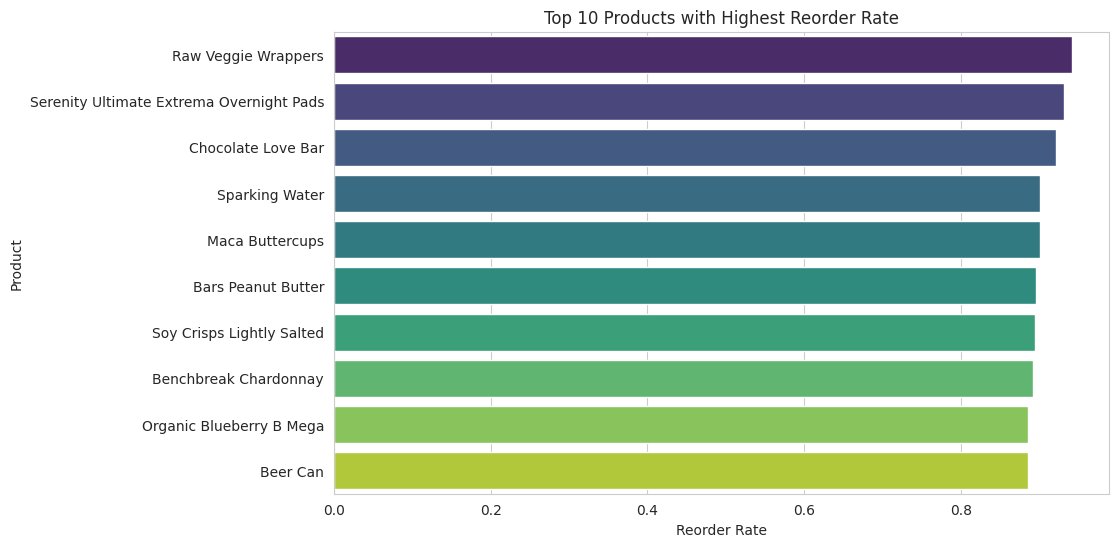

In [24]:
# Filter products that have been ordered more than 50 times to avoid small-sample bias,
# then sort them by reorder rate (highest first) and select the top 10.
top_reordered = product_summary[product_summary['total_orders'] > 50] \
    .sort_values('reorder_rate', ascending=False).head(10)

# Create a new figure for the bar plot with defined size (width=10, height=6 inches)
plt.figure(figsize=(10,6))

# Plot a bar chart showing the products with the highest reorder rate.
# Using the product name as hue assigns different colors to each product for clearer distinction.
sns.barplot(x='reorder_rate', y='product_name', data=top_reordered,
            hue='product_name', palette='viridis')

# Add a title describing what the visualization represents
plt.title('Top 10 Products with Highest Reorder Rate')

# Label the x-axis to indicate values represent reorder percentages
plt.xlabel('Reorder Rate')

# Label the y-axis to list the product names
plt.ylabel('Product')

# Display the final visualization
plt.show()


 The products shown are consistently added to the cart early, implying they are either planned purchases, high-priority items, or items customers specifically search for before browsing. However, since values are close, the individual ranking is less insightful than understanding which categories dominate early-cart behavior.

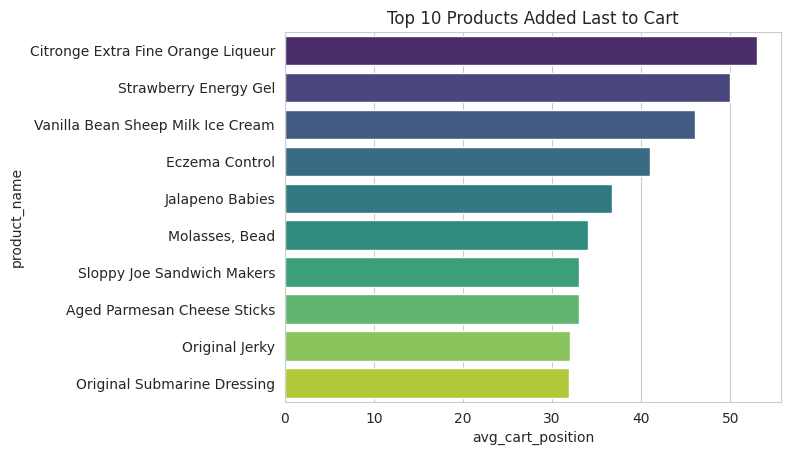

In [25]:
# Select the top 10 products that tend to be added last in the shopping cart,
# by sorting in descending order based on average cart position.
late_items = product_summary.sort_values('avg_cart_position', ascending=False).head(10)

# Create a bar plot showing the average cart position for these items.
# 'x' represents how late the product is added in the order process.
# The 'hue' parameter gives each bar a unique color for better visual distinction.
sns.barplot(x='avg_cart_position', y='product_name', data=late_items,
            hue='product_name', palette='viridis')

# Add a title describing what the visualization represents.
plt.title("Top 10 Products Added Last to Cart")

# Display the completed plot.
plt.show()


#References
OpenAI. (2025). ChatGPT (GPT-5.1) [Large language model]. https://chat.openai.com/ available at https://chatgpt.com/c/691d1e06-7d20-8332-8018-e7ee878a0b85  

Yasser, M. (2022, January 25). InstaCart Online Grocery Basket Analysis Dataset. Kaggle. Retrieved November 18, 2025, from https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset




#Declaration

This notebook includes content created with assistance from ChatGPT (OpenAI GPT-5.1). The AI tool was used to support understanding of data preprocessing, visualization techniques, feature engineering logic, and communication clarity. All final code execution, decisions, interpretations, and structure were reviewed, revised, and implemented by the authors - Group 9.